                                   Name    Duration
0            MegaBlock generate indices  450.119550
1               MegaBlock generate topo  590.622510
2                 MegaBlock mlp forward  553.707380
3   MegaBlock padded and reorder tokens  226.428410
4  MegaBlock reorder and remove padding  160.342920
5           MegaSparse generate indices  477.047210
6              MegaSparse generate topo  778.842388
7                             MoE route  270.379120


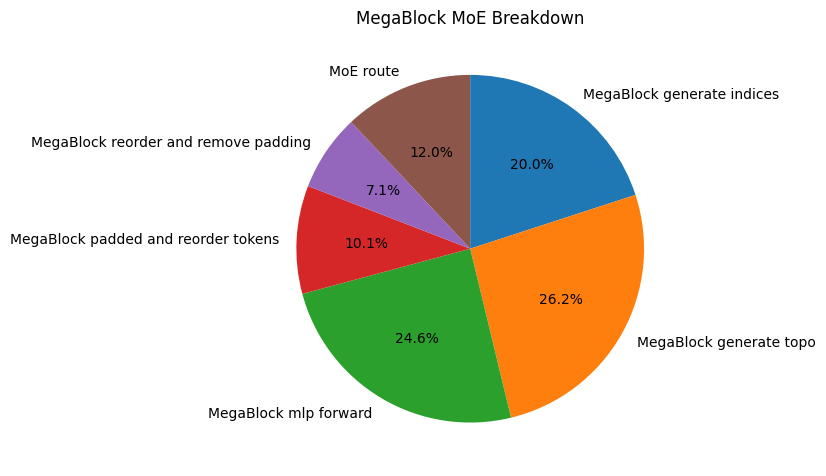

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("moe_breakdown_warmup20_iter100.csv")

df["Duration"] = df["Duration"].astype(str).str.replace(" μs", "", regex=False).astype(float)

mean_df = df.groupby("Name", as_index=False)["Duration"].mean()

print(mean_df)

sparse_names = ["MegaSparse generate topo", "MegaSparse generate indices"]

main_df = mean_df[~mean_df["Name"].isin(sparse_names)].copy()
excluded_df = mean_df[mean_df["Name"].isin(sparse_names)].copy()

plt.figure(figsize=(8, 8))
plt.pie(
    main_df["Duration"],
    labels=main_df["Name"],
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False
)
plt.title("MegaBlock MoE Breakdown")
plt.tight_layout()
plt.show()
